In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
np.random.seed(42)

class0 = np.random.randn(1000, 2) + [2, 2]
class1 = np.random.randn(1000, 2) + [6, 6]

X = np.vstack((class0, class1))
y = np.array([0]*1000 + [1]*1000)

df = pd.DataFrame(X, columns=["Nilai", "Pengalaman"])
df["Label"] = y

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
df.head(10)

,Nilai,Pengalaman,Label
0,6.995582,7.703173,1
1,0.719571,3.754794,0
2,6.848174,4.767477,1
3,1.516939,2.146793,0
4,6.280636,7.758620,1
5,4.622382,5.435226,1
6,1.437832,1.790778,0
7,6.156694,7.023531,1
8,0.449337,2.068563,0
9,5.629492,4.594433,1


In [ ]:
df.shape

(2000, 3)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Nilai       2000 non-null   float64
 1   Pengalaman  2000 non-null   float64
 2   Label       2000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 47.0 KB


## Check data yang hilang

In [ ]:
df.isnull().sum()

,0
Nilai,0
Pengalaman,0
Label,0


## Check dupilacted data

In [ ]:
df.duplicated().sum()

np.int64(0)

## Hitung nilai untuk setiap kategori (Label)

In [ ]:
df['Label'].value_counts()

,count
Label,
1,1000
0,1000


## Cari rata-rata nilai kemudian hitung berapa banyak nilai yang melebih rata-rata

In [ ]:
a = df['Nilai'].mean()
print(a)

b = (df['Nilai'] > a).sum()
print(b)

4.0111843618905345
1002


In [ ]:
df[df["Nilai"] > df["Nilai"].mean()]

,Nilai,Pengalaman,Label
0,6.995582,7.703173,1
2,6.848174,4.767477,1
4,6.280636,7.758620,1
5,4.622382,5.435226,1
7,6.156694,7.023531,1
...,...,...,...
1994,4.401876,6.462173,1
1995,6.436739,6.404295,1
1996,5.199961,5.936475,1
1998,6.098068,7.295872,1


## Tampilkan visualisasi distribusi untuk kolom nilai dan pengalaman kemudian jelaskan informasi yang diperoleh

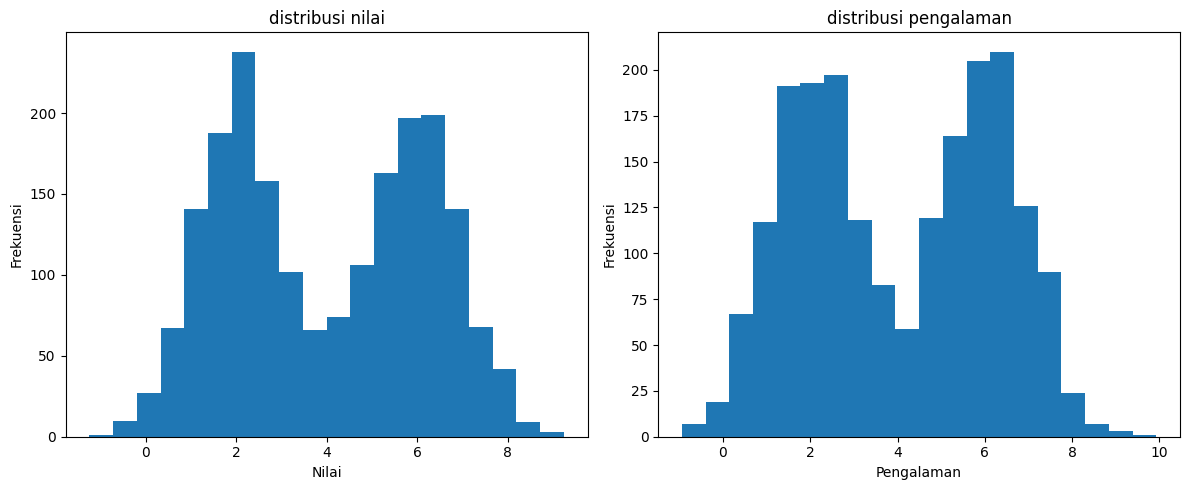

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(df['Nilai'], bins=20)
plt.title('distribusi nilai')
plt.xlabel('Nilai')
plt.ylabel('Frekuensi')

plt.subplot(1,2,2)
plt.hist(df['Pengalaman'],bins=20)
plt.title('distribusi pengalaman')
plt.xlabel('Pengalaman')
plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()

## Bandingkan dengan scatter plot kemudian apa hasil yang diperoleh

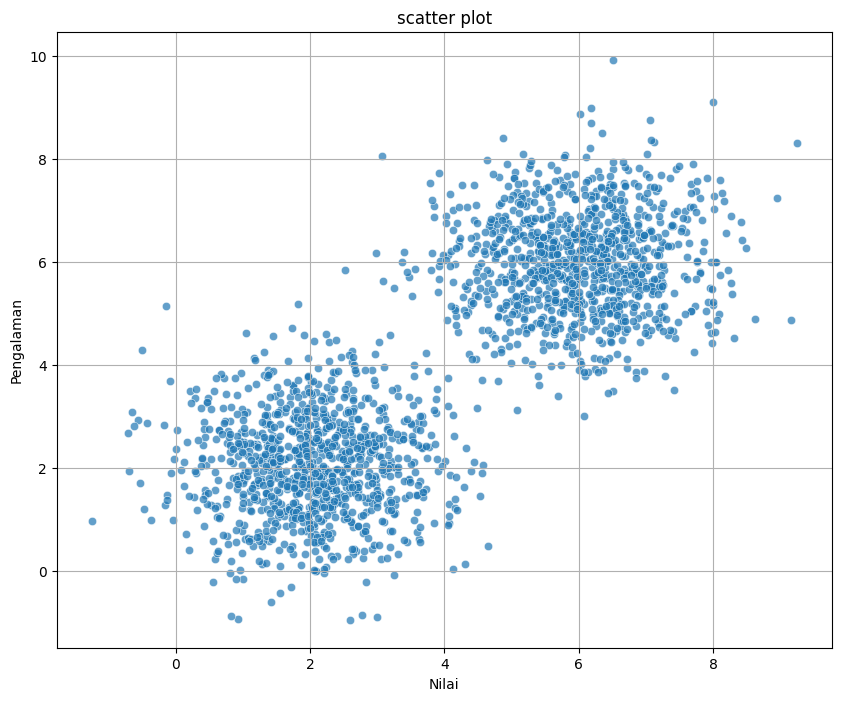

In [ ]:
plt.figure(figsize=(10,8))
sns.scatterplot(x='Nilai', y='Pengalaman', data = df, alpha = 0.7)
plt.title('scatter plot')
plt.xlabel('Nilai')
plt.ylabel('Pengalaman')
plt.grid(True)
plt.show()

## Cari hubungan antar kolom, kemudian jelaskan maksud dari hubungan tersebut

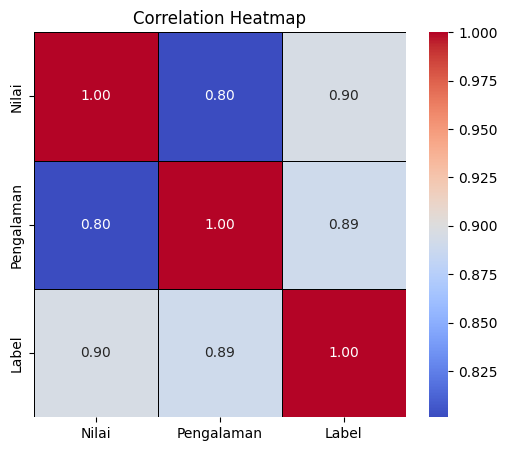

In [ ]:
correlation_all = df[['Nilai', 'Pengalaman', 'Label']].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(correlation_all, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5 ,linecolor='black')
plt.title('Correlation Heatmap')
plt.show()

## Buat variable baru untuk menampung variable dependent dan independet. Variable dependent adalah kolom label dan variable independent adalah kolom nilai dan pengalaman. Simpan variable dependent dengan nama (y) dan variable independent (X)

In [ ]:
x= df [['Nilai', 'Pengalaman']]
y= df ['Label']

print("Variabel Independent (x):")
print(x.head())

print("\nVariabel Dependent (y):")
print(y.head())


Variabel Independent (x):
      Nilai  Pengalaman
0  6.995582    7.703173
1  0.719571    3.754794
2  6.848174    4.767477
3  1.516939    2.146793
4  6.280636    7.758620

Variabel Dependent (y):
0    1
1    0
2    1
3    0
4    1
Name: Label, dtype: int64


## Dari variable yang sudah dibuat split menjadi train dan test menggunakan train test split, ukuran data test sebesar 25% dengan random_state=42 setelah itu check ukuran data untuk setiap test dan trainnya

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=42
)

print('ukuran x_train:', x_train.shape)
print('ukuran x_test:', x_test.shape)
print('ukuran y_train:', y_train.shape)
print('ukuran y_test:', y_test.shape)

ukuran x_train: (1500, 2)
ukuran x_test: (500, 2)
ukuran y_train: (1500,)
ukuran y_test: (500,)


## Model SVM merupakan model yang sensitif terhadap jarak, sehingga perlu dilakukan normalisasi atau standarisasi. Lakukan normalisasi atau standarisasi hanya untuk data X_train dan X_test saja

In [ ]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Data x_train :")
print(x_train[:5])
print("Data x_train_scaled :")
print(x_train_scaled[:5])

print("Data test :")
print(x_test[:5])
print("Data x_test_scaled :")
print(x_test_scaled[:5])


Data x_train :
         Nilai  Pengalaman
1738  7.676393    5.054493
548   5.602320    4.815969
936   1.076767    0.648315
1389  3.085786    2.097983
1607  7.393455    6.710549
Data x_train_scaled :
[[ 1.6855135   0.47717991]
 [ 0.73896846  0.37005047]
 [-1.32635946 -1.50179065]
 [-0.40950274 -0.85069349]
 [ 1.55638879  1.22097334]]
Data test :
         Nilai  Pengalaman
1860  6.714610    3.950059
353   4.949859    6.757495
1333  3.189470    0.772392
905   8.049812    6.000683
1289  2.625667    1.142842
Data x_test_scaled :
[[ 1.24658426 -0.01886072]
 [ 0.44120466  1.24205847]
 [-0.36218437 -1.44606337]
 [ 1.85593085  0.90214723]
 [-0.61948734 -1.27968103]]


## Buat model SVM menggunakan data yang sudah discale atau normalisasi, model svm yang digunakan adalah linear dengan parameter c sebesar 100

In [ ]:
svmmodel = SVC(kernel='linear', C=100, random_state=42)
svmmodel.fit(x_train_scaled, y_train)

SVC(C=100, kernel='linear', random_state=42)

## Buat variable untuk mempredict nilai yang diperoleh dari hasil training kemudian berapa nilai yang diperoleh dan apa arti nilai tersebut?

In [ ]:
y_pred = svmmodel.predict(x_test_scaled)
akurasi = accuracy_score(y_test, y_pred)
print("Akurasi model:", akurasi)

Akurasi model: 0.998


## Evaluasi model yang diperoleh dengan matriks pengukuran yang sesuai, apa arti dari hasil evaluasi model tersebut

In [ ]:
accuracy_score= accuracy_score(y_test, y_pred)
print(accuracy_score)
cm = confusion_matrix(y_test, y_pred)
print(cm)
cr = classification_report(y_test, y_pred)
print(cr)

0.998
[[240   1]
 [  0 259]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       241
           1       1.00      1.00      1.00       259

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg       1.00      1.00      1.00       500



## Dari model yang sudah dibuat, lakukan percobaan untuk memprediksi nilai baru kemudian lihat berapa nilai yang diperoleh

In [ ]:
fitur = x_train.columns.tolist()
print("fitur yg dibutuhkan : ", fitur)

nilai_baru = [[5.0, 5.0]]

data_baru = pd.DataFrame(nilai_baru, columns=fitur)
data_baru_scaled = scaler.transform(data_baru)

prediksi = svmmodel.predict(data_baru_scaled)
print(f"hasil prediksi: {prediksi[0]}")

fitur yg dibutuhkan :  ['Nilai', 'Pengalaman']
hasil prediksi: 1
